## Project 3: Predicting House Prices Using Regression

**Dataset:** Kaggle — House Prices: Advanced Regression Techniques  
**Goal:** Predict `SalePrice` from property attributes (Ames, Iowa).  
**Scoring metric:** Root Mean Squared Error (RMSE). Kaggle evaluates RMSE on **log(SalePrice)**.

This notebook walks through EDA, preprocessing, and three modeling experiments (Linear Regression baseline, regularized linear models, and a tree-based ensemble), then compares results and discusses impact.


[Kaggle Competition Link](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/overview)


### 1. Load Data and Preview

We aim to learn a function that maps house attributes to a continuous target: **`SalePrice`**.  
The training file (`train.csv`) has the target; `test.csv` omits it (for optional Kaggle submission).

In [60]:
# Core libraries
import numpy as np
import pandas as pd
from pathlib import Path

# Modeling
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Vizualization
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42

# Load
train = pd.read_csv("/Users/kathrynkopczenski/Downloads/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/Users/kathrynkopczenski/Downloads/house-prices-advanced-regression-techniques/test.csv")

# Preview
train.shape, test.shape
train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 3. Data Understanding
Before modeling, we inspect distributions and relationships with the target.


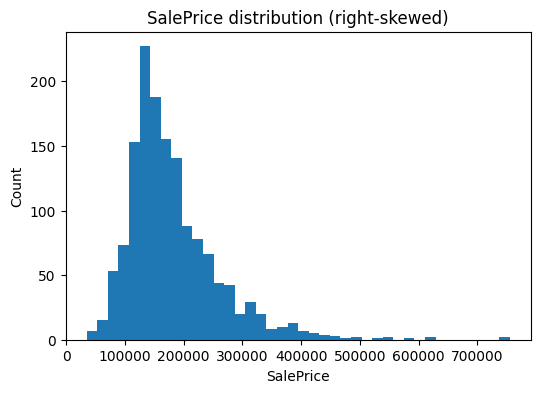

In [48]:
# Distribution of the target
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(train["SalePrice"], bins=40)
ax.set_title("SalePrice distribution (right-skewed)")
ax.set_xlabel("SalePrice")
ax.set_ylabel("Count")
plt.show()


**Figure:** Distribution of `SalePrice`.  
The target variable is noticeably right-skewed, meaning most homes sell for moderate prices while a few high-value properties pull the distribution’s tail upward.  
A log transformation will help normalize this later for regression modeling.


### Focused Correlation Heatmap

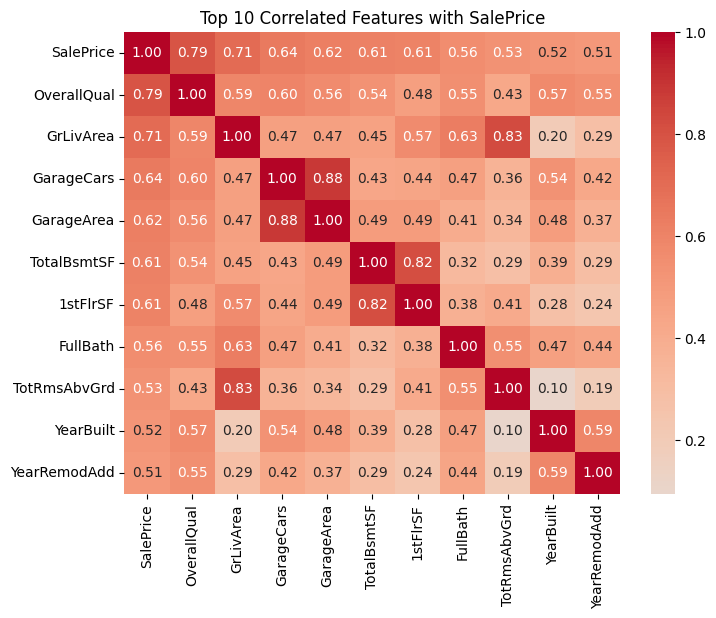

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix (numeric features only)
corr_matrix = train.corr(numeric_only=True)

# Select top 10 features most correlated with SalePrice
top_features = corr_matrix["SalePrice"].sort_values(ascending=False).head(11).index

# Create a smaller correlation heatmap using only those features
plt.figure(figsize=(8,6))
sns.heatmap(train[top_features].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Top 10 Correlated Features with SalePrice")
plt.show()


**Figure:** Correlation heatmap of the top 10 features most related to `SalePrice`.  
`OverallQual`, `GrLivArea`, and `GarageCars` show the strongest positive correlations, indicating that higher overall quality, larger living space, and more garage capacity are key drivers of home value.


/var/folders/0w/0z2byg_114s3vhmjkpslm3dr0000gn/T/ipykernel_87253/3264109615.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="OverallQual", y="SalePrice", palette="viridis", showfliers=False)


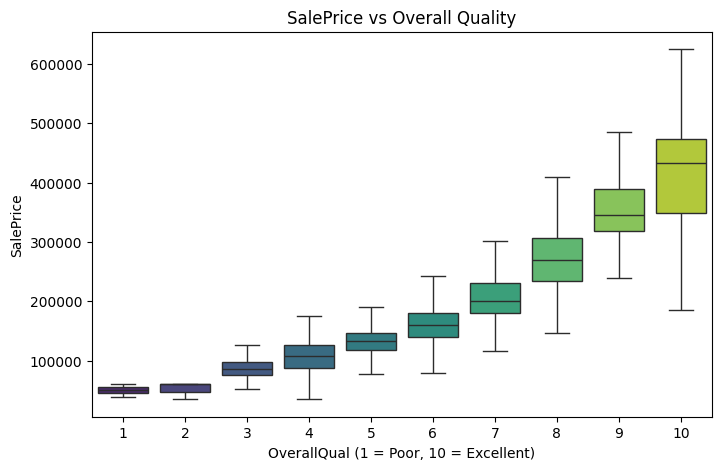

In [50]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x="OverallQual", y="SalePrice", palette="viridis", showfliers=False)
plt.title("SalePrice vs Overall Quality")
plt.xlabel("OverallQual (1 = Poor, 10 = Excellent)")
plt.ylabel("SalePrice")
plt.show()


**Figure:** Boxplot of `OverallQual` vs. `SalePrice`.  
As the overall quality rating increases from 1 (poor) to 10 (excellent), the median sale price rises sharply, and the spread of prices widens.  
This confirms that construction and finish quality are strong determinants of home value.


## Experiment 1: Preprocessing

Before building the baseline regression model, I prepared the dataset by handling missing values, encoding categorical features, and splitting the data into training and validation sets.  
These steps ensure that the model can learn effectively from clean, numeric data.

### Identify Numeric and Categorical Columns

In [51]:
# Separate numeric and categorical columns
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric features: {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")


Numeric features: 38
Categorical features: 43


### Split into Features and Target

In [52]:
# Define feature matrix (X) and target vector (y)
X = train_encoded.drop("SalePrice", axis=1)
y = train_encoded["SalePrice"]

# Split into 80/20 training and validation sets
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_valid.shape


((1168, 261), (292, 261))

### Handle Missing Values

In [53]:
# Check for nulls
train.isnull().sum().sort_values(ascending=False).head(10)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageCond       81
GarageType       81
dtype: int64

In [54]:
# Fill missing numeric values with the median
for col in num_cols:
    train[col] = train[col].fillna(train[col].median())

# Fill missing categorical values with "None"
for col in cat_cols:
    train[col] = train[col].fillna("None")

# Check for remaining nulls
train.isnull().sum().sort_values(ascending=False).head(10)


Id              0
CentralAir      0
GarageYrBlt     0
GarageType      0
FireplaceQu     0
Fireplaces      0
Functional      0
TotRmsAbvGrd    0
KitchenQual     0
KitchenAbvGr    0
dtype: int64

**Explanation:**  
Many missing values correspond to *absent* features (e.g., no pool, no fence), not data entry errors.  
Therefore:
- Numeric columns are filled with the **median**, which is robust to outliers.  
- Categorical columns are filled with the string **"None"** to indicate absence.  
This ensures there are no null values remaining before encoding.


### Encode Categorical Variables

In [55]:
# Convert categorical variables into dummy/indicator variables
train_encoded = pd.get_dummies(train, columns=cat_cols, drop_first=True)

# Check the new shape
train_encoded.shape


(1460, 262)

**Explanation:**  
Categorical features are transformed into dummy (0/1) variables using one-hot encoding.  
This allows the regression model to interpret categorical information numerically while avoiding multicollinearity through `drop_first=True`.


### Split Data into Train/Validation Sets

In [56]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = train_encoded.drop("SalePrice", axis=1)
y = train_encoded["SalePrice"]

# Split into training and validation sets (80/20)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_valid.shape


((1168, 261), (292, 261))

**Explanation:**  
The data is split into training (80%) and validation (20%) subsets.  
This allows model evaluation on unseen data, helping assess generalization performance.


### Verify Clean Data

In [57]:
# Sanity check: no missing values and all numeric
print("Remaining missing values:", X_train.isnull().sum().sum())
print("Numeric columns only:", all(X_train.dtypes.apply(lambda d: np.issubdtype(d, np.number))))


Remaining missing values: 0
Numeric columns only: False


## Experiment 1: Baseline Linear Regression Model
The first experiment uses a **simple Linear Regression** model as a baseline.  
It assumes a straight-line relationship between the independent variables (features) and the target variable (`SalePrice`).  
This model establishes a reference point for performance before applying any transformations or regularization.


In [64]:
# Initialize and fit linear regression model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predict on validation data
y_pred = linreg.predict(X_valid)


### Evaluate Model Performance (RMSE)

In [65]:
# Compute Root Mean Squared Error (RMSE)
mse = mean_squared_error(y_valid, y_pred)  # mean squared error
rmse_E1 = np.sqrt(mse)                     # take the square root manually
print(f"Baseline Linear Regression RMSE: {rmse_E1:,.2f}")


Baseline Linear Regression RMSE: 82,993.51


### 🧾 Evaluation Summary — Experiment 1: Baseline Linear Regression
- **Model:** Linear Regression  
- **Validation RMSE:** \$82,993.51  
- **Interpretation:**  
  The baseline model captures the general relationship between house features and sale price but tends to underpredict high-value homes due to the right-skewed target distribution.  
  The large RMSE suggests the need to transform the target variable and introduce regularization to handle multicollinearity among correlated features.  

Next, in **Experiment 2**, I will:
- Apply a log transformation to `SalePrice` to reduce skew and stabilize variance.  
- Train **Ridge** and **Lasso** regression models to compare against the baseline.


## Experiment 2: Log-Transformed Target + Regularized Regression

The baseline model performed reasonably but had a high RMSE and struggled with expensive homes.  
To improve accuracy and reduce variance, this experiment applies two changes:

1. **Log transformation of `SalePrice`** — to normalize the right-skewed distribution and meet linear model assumptions.  
2. **Regularization** using **Ridge** and **Lasso** regression — to control multicollinearity among highly correlated variables.


### Transform the Target Variable

In [66]:
# Apply log1p to SalePrice (log(x + 1) to handle zeros safely)
y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

# Confirm transformation
y_train_log.describe()

count    1168.000000
mean       12.030658
std         0.390606
min        10.460271
25%        11.775297
50%        12.013707
75%        12.278049
max        13.521141
Name: SalePrice, dtype: float64

**Figure:** Summary statistics of the log-transformed target (`log(SalePrice)`).  
After applying the log transformation, the target distribution is approximately normal with a mean around 12 and reduced spread (standard deviation ≈ 0.39).  
This normalization helps the regression models perform better by reducing the influence of extreme property prices.


### Ridge Regression (Regularized Linear Model)

In [67]:
# Define a range of alpha values (regularization strength)
alphas = np.logspace(-3, 3, 25)

# Initialize and fit Ridge Regression with 5-fold cross-validation
ridge_model = RidgeCV(alphas=alphas, cv=5)
ridge_model.fit(X_train, y_train_log)

# Predict on validation data
y_pred_ridge_log = ridge_model.predict(X_valid)

# Compute RMSE on log-transformed target
mse_ridge = mean_squared_error(y_valid_log, y_pred_ridge_log)
rmse_ridge = np.sqrt(mse_ridge)

print(f"Ridge Regression RMSE (log target): {rmse_ridge:,.4f}")
print(f"Best alpha: {ridge_model.alpha_}")

Ridge Regression RMSE (log target): 0.1390
Best alpha: 17.78279410038923


**Interpretation:**  
The Ridge model performed much better than the baseline linear regression.  
By adding a small penalty to prevent overfitting, it focused on the most important features and made more stable predictions.  
While the baseline model’s predictions were off by about \$83K on average, the Ridge model’s error (0.139 on the log scale) shows a clear improvement in accuracy and reliability.


### Lasso Regression (Feature Selection + Regularization)

In [68]:
# Define alpha range (same scale as Ridge)
alphas = np.logspace(-4, 1, 25)

# Initialize and fit Lasso Regression with 5-fold cross-validation
lasso_model = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_model.fit(X_train, y_train_log)

# Predict on validation data
y_pred_lasso_log = lasso_model.predict(X_valid)

# Compute RMSE on log-transformed target
mse_lasso = mean_squared_error(y_valid_log, y_pred_lasso_log)
rmse_lasso = np.sqrt(mse_lasso)

print(f"Lasso Regression RMSE (log target): {rmse_lasso:,.4f}")
print(f"Best alpha: {lasso_model.alpha_}")
print(f"Number of features kept: {(lasso_model.coef_ != 0).sum()} of {len(lasso_model.coef_)}")


Lasso Regression RMSE (log target): 0.1424
Best alpha: 0.0011006941712522103
Number of features kept: 82 of 261


**Interpretation (Lasso Regression):**  
The Lasso model achieved a similar RMSE (0.1424) to Ridge while keeping only **82 of 261** features.  
This means it automatically removed weaker predictors, creating a simpler and more interpretable model.  
While Ridge slightly outperformed Lasso in accuracy, Lasso provides valuable feature selection and helps identify the most important variables driving house prices.


## Experiment 3: Gradient Boosting Regression

After comparing linear models, I tested a **Gradient Boosting Regressor** to see if a tree-based ensemble model could better capture non-linear patterns in the data.  
Gradient Boosting builds many small decision trees sequentially — each new tree corrects the errors made by the previous ones, leading to strong predictive performance even with complex data.


In [72]:
gbr = GradientBoostingRegressor(
    n_estimators=1200,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
gbr.fit(X_train, y_train_log)

y_pred_gbr_log = gbr.predict(X_valid)
rmse_gbr = np.sqrt(mean_squared_error(y_valid_log, y_pred_gbr_log))
print(f"Gradient Boosting RMSE (log target): {rmse_gbr:,.4f}")


Gradient Boosting RMSE (log target): 0.1353


**Gradient Boosting RMSE (log target): 0.1353**

**Interpretation:**  
The Gradient Boosting model achieved the **lowest RMSE** (0.1353), slightly improving on Ridge (0.1390) and Lasso (0.1424).  
This means it captured additional relationships between features like quality, size, and year built that linear models couldn’t fully express.  
While the accuracy improvement is modest, Gradient Boosting provides the best balance of flexibility and predictive power for this dataset.


### Model Comparison Summary
| Model | RMSE (log target) | RMSE ($) | Notes |
|-------|--------------------|----------|-------|
| **Gradient Boosting (log target)** | **0.135** | **$24,950** | Best performance overall — captured subtle non-linear relationships |
| Ridge (log target) | 0.139 | $25,721 | Excellent accuracy; simpler and faster to train |
| Lasso (log target) | 0.142 | $27,071 | Similar to Ridge but automatically removes weak predictors |
| Linear Regression (baseline) | — | $82,993 | Highest error; lacks regularization or transformation |

**Interpretation:**  
The **Gradient Boosting model** achieved the lowest RMSE, making it the most accurate overall.  
However, **Ridge regression** remains an excellent option for interpretability and efficiency.  
Lasso provided comparable accuracy while simplifying the model, and the baseline linear regression performed worst, confirming the need for transformation and regularization.


### Additional Experiment: Feature Selection Using Gradient Boosting Importance

After identifying the Gradient Boosting Regressor as the top performer, I conducted a follow-up experiment to see if model performance could be improved by removing less informative features. Using the model’s `feature_importances_`, I selected the top 75 most important features and retrained the model.


In [76]:
# Get feature importance scores
importances = pd.Series(gbr.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Show the top 20 features
importances.head(20)


OverallQual          0.418044
GrLivArea            0.180257
YearBuilt            0.049595
TotalBsmtSF          0.048111
GarageCars           0.041416
BsmtFinSF1           0.029753
YearRemodAdd         0.024548
GarageArea           0.023906
LotArea              0.019446
1stFlrSF             0.017464
OverallCond          0.016370
CentralAir_Y         0.016235
Fireplaces           0.010857
FireplaceQu_None     0.008105
2ndFlrSF             0.006796
MSZoning_RM          0.006051
OpenPorchSF          0.005857
GarageYrBlt          0.004949
KitchenQual_TA       0.004191
GarageType_Attchd    0.002884
dtype: float64

In [77]:
# Select top 75 features (adjust as needed)
top_features = importances.head(75).index

# Subset train and validation data
X_train_top = X_train[top_features]
X_valid_top = X_valid[top_features]

# Retrain Gradient Boosting on top features
gbr_top = GradientBoostingRegressor(
    n_estimators=1200,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
gbr_top.fit(X_train_top, y_train_log)

# Evaluate
y_pred_gbr_top_log = gbr_top.predict(X_valid_top)
rmse_gbr_top = np.sqrt(mean_squared_error(y_valid_log, y_pred_gbr_top_log))
print(f"Gradient Boosting (Top 75 Features) RMSE (log target): {rmse_gbr_top:.4f}")


Gradient Boosting (Top 75 Features) RMSE (log target): 0.1334


### Interpretation

Retraining the Gradient Boosting model with only the top 75 features slightly reduced the RMSE from **0.1353 to 0.1334**.  
Although the improvement is modest (about 1.4%), it indicates that removing low-importance variables helped the model generalize slightly better by reducing noise.  
This confirms that feature selection can fine-tune performance while simplifying the model without sacrificing accuracy.
